#### Import Libraries

In [1]:
import pytato as yt
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [1]:
import pytato
import inspect
print(f"Package location: {inspect.getfile(pytato)}")
print(f"Package directory: {pytato.__path__}")

Package location: C:\Users\tcoop\AppData\Roaming\Python\Python313\site-packages\pytato\__init__.py
Package directory: ['C:\\Users\\tcoop\\AppData\\Roaming\\Python\\Python313\\site-packages\\pytato']


## Example of Single Enzyme Digestion

### Import Proteome

In [ ]:
proteome_df = yt.Silico().import_fasta(source="https://ftp.uniprot.org/pub/databases/uniprot/current_release/knowledgebase/reference_proteomes/Eukaryota/UP000005640/UP000005640_9606.fasta.gz")

#### (Optional) Add Enzyme

In [4]:
# silico.rules['CL3'] = '(L|Q)(?=S|A|G)'

## Digest Proteome

In [5]:
results = []
silico = yt.Silico()  
silico.missed = 1
peptide_properties_dic = silico.generate_samples(proteome_df,
                                                  enzyme="thermolysin",
                                                 target="Peptide",
                                                  identifier="Gene",
                                                    pH=2,
                                                    min_charge=0)
peptides_df = pd.DataFrame(peptide_properties_dic)



Generated 1643176 peptides matching criteria.


In [6]:
peptides_df.head()

,Gene,peptide,Length,aa_comp,neutral_z,z,Mass,GRAVY,m/z
0,A0A2U3TZM8,MDASSSPWNPTP,12,"{'M': 1, 'W': 1, 'T': 1, 'P': 3, 'A': 1, 'S': ...",-1,1,1270.528837,-1.008333,1270.528837
1,A0A2U3TZM8,ASSSPWNPTP,10,"{'W': 1, 'T': 1, 'P': 3, 'A': 1, 'S': 3, 'N': 1}",0,1,1024.461409,-1.050000,1024.461409
2,A0A2U3TZM8,ASSSPWNPTPAP,12,"{'W': 1, 'T': 1, 'P': 4, 'A': 2, 'S': 3, 'N': 1}",0,1,1192.551287,-0.858333,1192.551287
3,A0A2U3TZM8,APVSSPP,7,"{'P': 3, 'V': 1, 'A': 1, 'S': 2}",0,1,635.327876,-0.057143,635.327876
4,A0A2U3TZM8,AQGCCADGSSPCRKQGSSGPPDCCWTC,27,"{'R': 1, 'W': 1, 'G': 4, 'T': 1, 'P': 3, 'Q': ...",0,3,2686.963736,-0.555556,895.654579


#### Determine number of peptides per gene

In [7]:
print(len(peptides_df))
peptides_df = peptides_df[peptides_df['z'] <= 6]
print(len(peptides_df))
peptide_counts = peptides_df.groupby('Gene').size()
print(peptide_counts)

1643176
1603990
Gene
1433B     36
1433E     31
1433F     38
1433G     37
1433S     34
        ... 
ZY11A     71
ZY11B     76
ZYX       97
ZZEF1    411
ZZZ3     164
Length: 20626, dtype: int64


#### Peptide Properties

In [8]:
# yt.Plots.petide_hex()

<Figure size 500x400 with 0 Axes>

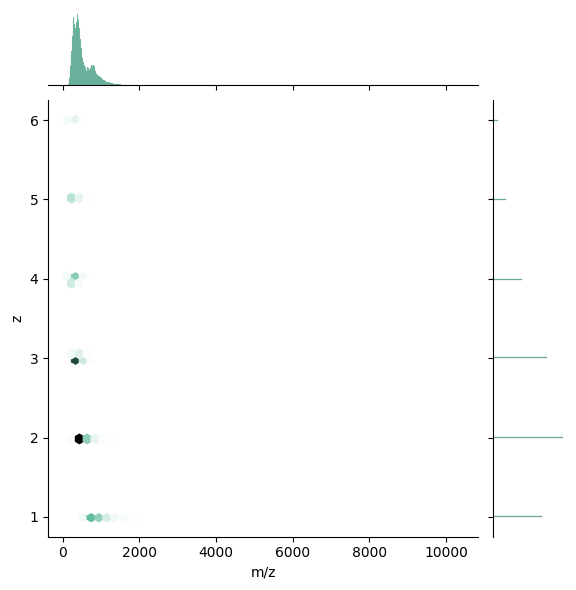

In [9]:
x = peptides_df['m/z']
y = peptides_df['z']

plt.figure(figsize=(5, 4))
sns.jointplot(x=x, y=y, kind="hex", color="#4CB391")


plt.show()

6
1603990
1603990
345901


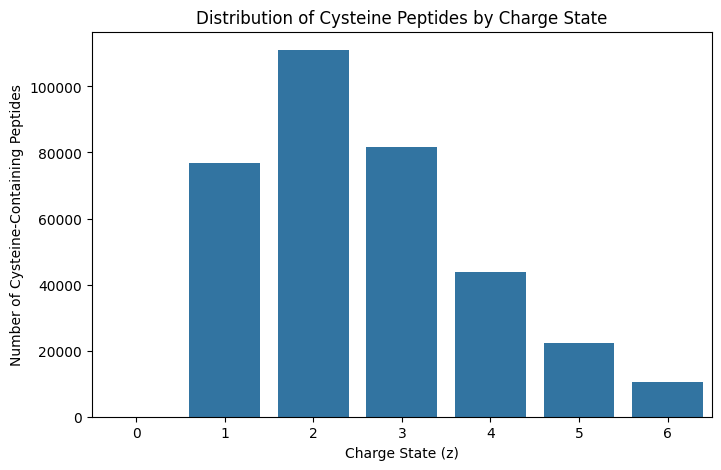

In [10]:
## need to filter for protiens with z = 1
## need to filter for peptides with Cysteiine

# Filter for peptides with charge state z=1
z_peptides = peptides_df[peptides_df['z'] <= 6]
print(z_peptides.z.max())
cys_peptides = z_peptides[z_peptides['peptide'].str.contains('C')]

print(len(peptides_df))
print(len(z_peptides))
print(len(cys_peptides))

#I want to make a bar graph where x is the z and y is the number of peptides containing cysteine

# Count peptides containing cysteine for each charge state
cys_by_charge = cys_peptides['z'].value_counts().sort_index()

plt.figure(figsize=(8,5))
sns.barplot(x=cys_by_charge.index, y=cys_by_charge.values)
plt.xlabel('Charge State (z)')
plt.ylabel('Number of Cysteine-Containing Peptides')
plt.title('Distribution of Cysteine Peptides by Charge State')
plt.show()



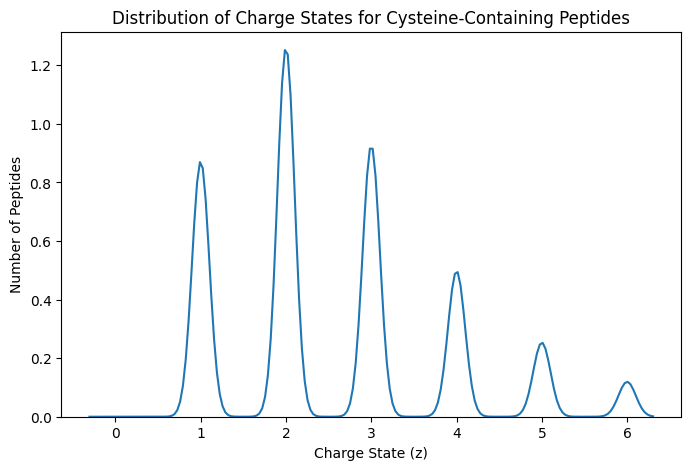

In [11]:
#using the cys_peptides dataframe, I want to make distrbution plot where z is on the x axis and the number of peptides is on the y axis
cys_peptides = z_peptides[z_peptides['peptide'].str.contains('C')]
plt.figure(figsize=(8,5))
sns.kdeplot(data=cys_peptides, x='z',common_norm=True)
plt.xlabel('Charge State (z)')
plt.ylabel('Number of Peptides')
plt.title('Distribution of Charge States for Cysteine-Containing Peptides')
plt.show()



In [12]:
cys_by_charge

z
0         4
1     76769
2    111004
3     81579
4     43772
5     22285
6     10488
Name: count, dtype: int64

In [13]:
modified_peptides_df = cys_peptides.copy()
modified_peptides_df['C_count'] = modified_peptides_df['peptide'].str.count('C')
print(modified_peptides_df.z.max())
# Add mass shift and charge for each cysteine
modified_peptides_df['m/z'] = modified_peptides_df.apply(lambda x: x['m/z'] + (105.0578 * x['C_count']) if pd.notnull(x['m/z']) else x['m/z'], axis=1)
modified_peptides_df['z'] = modified_peptides_df['z'] + modified_peptides_df['C_count']
print(modified_peptides_df.z.max())
# Drop the temporary C_count column
modified_peptides_df.drop('C_count', axis=1, inplace=True)





6
36


In [14]:
# Count peptides containing cysteine for each charge state
cys_by_charge_mod = modified_peptides_df['z'].value_counts().sort_index()
cys_by_charge_mod


z
1          4
2      62339
3     100267
4      83944
5      49581
6      26642
7      15259
8       5565
9       1153
10       448
11       206
12       118
13        69
14        76
15        28
16        44
17        34
18        21
19        33
20        17
21        11
22         2
23        10
24         4
25         2
26         4
27         4
28         3
29         1
30         3
32         4
33         1
34         1
35         1
36         2
Name: count, dtype: int64

In [ ]:
#plot scatter plot of z vs length of modified peptides
plt.figure(figsize=(8,5))
sns.scatterplot(x='z', y='Length', data=modified_peptides_df)
plt.xlabel('Charge State (z)')
plt.ylabel('Peptide Length')
plt.title('Scatter Plot of Charge State vs Peptide Length for Modified Peptides')
plt.show()


In [ ]:
f, ax = plt.subplots(figsize=(6, 6))
x = modified_peptides_df['Length']
y = modified_peptides_df['z']
sns.scatterplot(x=x, y=y, s=5, color=".15")
sns.histplot(x=x, y=y, bins=10, pthresh=.1, cmap="mako")
sns.kdeplot(x=x, y=y, levels=5, color="w", linewidths=1)

In [ ]:

plt.figure(figsize=(8,5))
sns.kdeplot(data=cys_peptides, x='z', label='IAA', common_norm=False, color='green')
sns.kdeplot(data=modified_peptides_df, x='z', label='4-VPE', common_norm=False, color='purple')
plt.xlabel('z')
plt.xticks(range(0, 10, 2))
plt.ylabel('Density')
plt.title('Distribution of m/z Values: Modified vs Unmodified Peptides')
plt.legend()
plt.show()





In [ ]:
x = modified_peptides_df['m/z']
y = modified_peptides_df['z']

plt.figure(figsize=(5, 4))
sns.jointplot(x=x, y=y, kind='kde', color="#4CB391")


plt.show()